<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Day_25_Revising_Basics_BERT_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

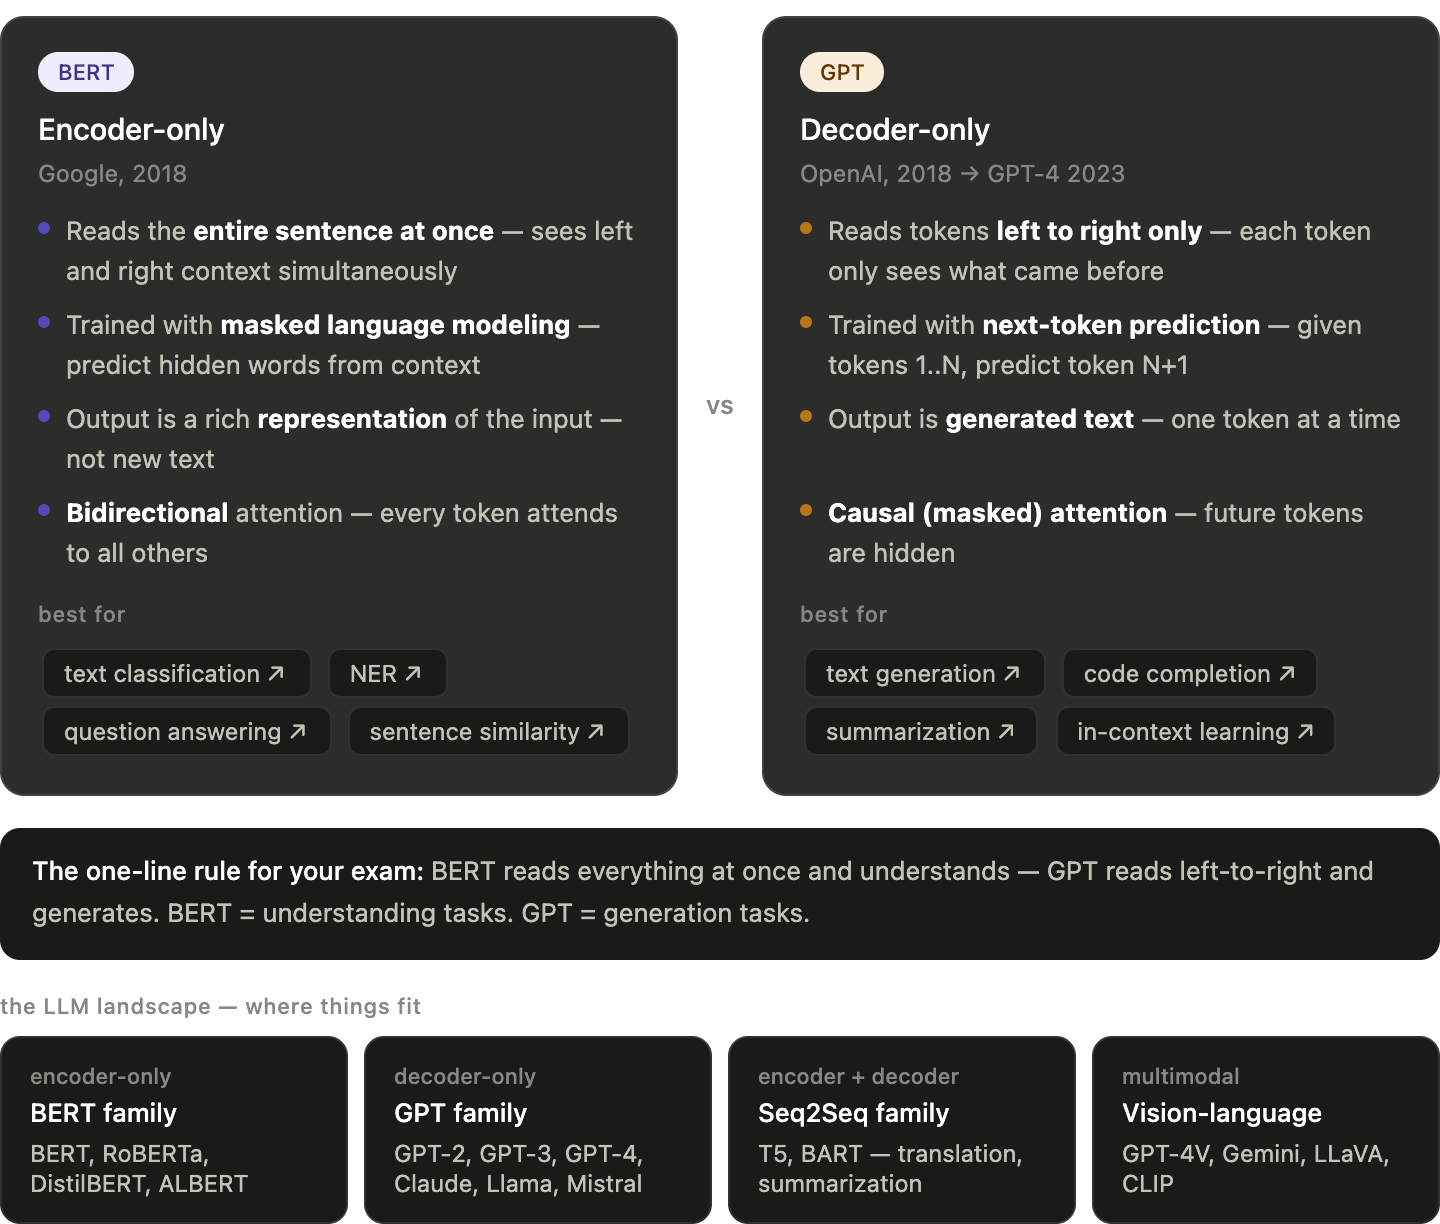

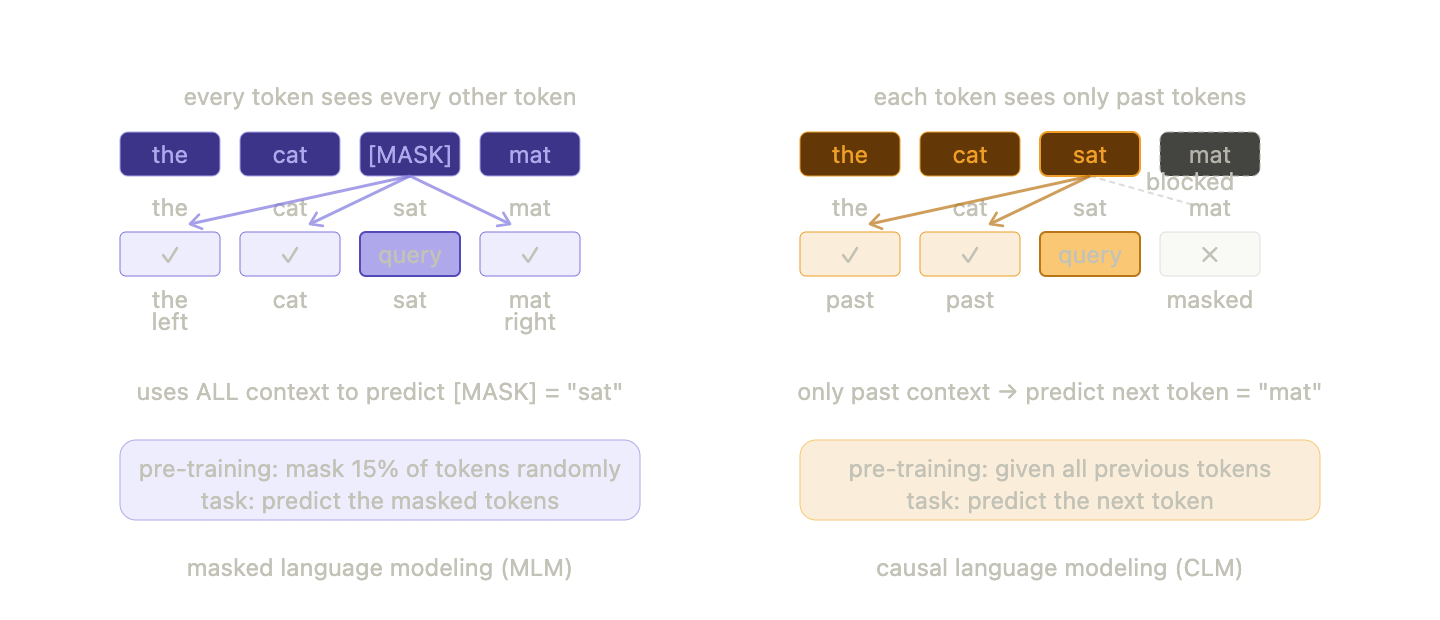

The grid is the key insight: BERT's attention matrix is fully connected — every token attends to every other. GPT's attention matrix is a lower triangle — the future is physically blocked. This is the difference between "understanding" and "generating."

## **Key concepts**
**The transformer is the shared foundation**. Both BERT and GPT are built on the same transformer block: multi-head self-attention + feedforward layer + layer norm. The difference is which parts they use and how they're trained.

**Pre-training vs fine-tuning**. Both models are trained in two stages. Pre-training happens on massive unlabeled text (Wikipedia, books, web). The model learns general language understanding. Fine-tuning happens on a small labeled dataset for your specific task. This is transfer learning — the heavy lifting is done once, then reused cheaply.

**Context window**. The maximum number of tokens a model can process at once. Early BERT: 512 tokens. GPT-4: ~128K tokens. Claude: up to 200K tokens. This matters for exams because exceeding the context window truncates input.

**Parameters and scale**. BERT-base has 110M parameters. GPT-3 has 175B parameters. Scale was the key discovery of the LLM era — bigger models trained on more data reliably become more capable, which was not obvious before 2020.

# **Coding Example**

In [7]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

In [2]:
bert_clf = pipeline("text-classification",
                    model="distilbert-base-uncased-finetuned-sst-2-english")
result = bert_clf("I absolutely loved this film!")
print(result)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999879002571106}]


In [3]:
gpt_gen = pipeline("text-generation",
                   model="gpt2")
result = gpt_gen("The cat sat on the", max_new_tokens=10)
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=T

The cat sat on the sofa as she walked across the room to her father


One line of code, Two completely different tasks — all because both models share the same pipeline() API. The full HuggingFace lab topic builds directly on this.